In [1]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil
from sklearn.metrics import f1_score, top_k_accuracy_score

# Импорт данных

In [ ]:
path = kagglehub.dataset_download(
    "gustavoachavez/architectural-styles-periods-dataset"
)
print("Kaggle cache path:", path)

destination_dir = "/data"

os.makedirs(destination_dir, exist_ok=True)

shutil.move(path, destination_dir)
print("Dataset moved to:", destination_dir)

# Приведение данных к удобному виду (без поддиректорий)

In [ ]:
!mv /data/1 /data/arch_dataset

In [ ]:
!ls -al /data/arch_dataset

In [ ]:
source_root = '/data/arch_dataset/Capstone_Architectural_Styles_dataset'

flat_root = '/data/arch_dataset/flat_dataset'
os.makedirs(flat_root, exist_ok=True)

classes = os.listdir(source_root)

for class_name in classes:
    class_dir = os.path.join(flat_root, class_name)
    os.makedirs(class_dir, exist_ok=True)

image_extensions = ('.jpg', '.jpeg', '.png')

for class_name in classes:
    source_class_path = os.path.join(source_root, class_name)
    target_class_path = os.path.join(flat_root, class_name)

    print(f"Processing {class_name}...")

    count = 0
    for root, _, files in os.walk(source_class_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                src_file = os.path.join(root, file)
                dst_file = os.path.join(target_class_path, file)

                if not os.path.exists(dst_file):
                    shutil.copy2(src_file, dst_file)
                    count += 1

    print(f"  → {count} изображений скопировано в {class_name}")


# Визуализация дисбаланса в данных

In [2]:
def count_images(main_root):
    counts = []
    for dirname in os.listdir(main_root):
        class_path = f'{main_root}/{dirname}'
        if os.path.isdir(class_path):
            total_files = sum(len(files) for _, _, files in os.walk(class_path))
            counts.append(total_files)
            print(f'{dirname}: {total_files}')
    return counts

In [3]:
import pandas as pd

source_root = '/data/arch_dataset/Capstone_Architectural_Styles_dataset'

flat_root = '/data/arch_dataset/flat_dataset'
classes = os.listdir(source_root)

styles_df = pd.DataFrame({
    'style': classes,
    'images': count_images(source_root) # [len(os.listdir(os.path.join(flat_root, cls))) for cls in classes]
})
styles_df

,style,images
0,Renaissance_and_Colonialism,1294
1,Early_Christian_Medieval,1338
2,Neoclassicism,1225
3,Classical,1022
4,Baroque,1089
5,Revivalism,1919
6,Eclecticism,1315
7,21st_Century,1229
8,Modernism,1860


In [4]:
import plotly.express as px

plot = px.bar(styles_df, x='style', y='images', title='Image count per style. Disbalance visualisation')
plot.show()

# Разделение на тренировочную, валидационную и тестовую выборки

In [ ]:
from sklearn.model_selection import train_test_split
import random

for split in ['train', 'val', 'test']:
    split_path = os.path.join(flat_root, split)
    os.makedirs(split_path, exist_ok=True)

random.seed(42)

print("Splitting classes...")
for class_name in classes:
    print(f"  {class_name}...")

    class_path = os.path.join(flat_root, class_name)
    files = os.listdir(class_path)

    train_files, temp_files = train_test_split(files, train_size=0.8, random_state=42)
    val_files, test_files = train_test_split(temp_files, train_size=0.5, random_state=42)

    for split_name, split_files in [('train', train_files), ('val', val_files), ('test', test_files)]:
        src_dir = class_path
        dst_dir = os.path.join(flat_root, split_name, class_name)
        os.makedirs(dst_dir, exist_ok=True)

        for file in split_files:
            shutil.move(os.path.join(src_dir, file), os.path.join(dst_dir, file))

    print(f"    → train: {len(train_files)}, val: {len(val_files)}, test: {len(test_files)}")

    if not os.listdir(class_path):
        os.rmdir(class_path)
        print(f"Deleted empty dir: {class_name}")

# Преобразование данных в тензоры + аугментация

In [5]:
# Make transforms and use data loaders # We'll use these a lot, so make them variables
mean_nums = [0.485, 0.456, 0.406]
std_nums = [0.229, 0.224, 0.225]
chosen_transforms = {'train': transforms.Compose([ transforms.RandomResizedCrop(size=224), transforms.RandomRotation(degrees=15), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(mean_nums, std_nums) ]), 'val': transforms.Compose([ transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize(mean_nums, std_nums) ]), 'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean_nums, std_nums)
    ])}

In [6]:
data_dir = flat_root

chosen_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), chosen_transforms[x]) for x in ['train', 'val', 'test']}

In [7]:
dataloaders = {x: torch.utils.data.DataLoader(chosen_datasets[x], batch_size=4, shuffle=(x == 'train'), num_workers=4) for x in ['train', 'val', 'test']}

In [8]:
dataset_sizes = {x: len(chosen_datasets[x]) for x in ['train', 'val', 'test']}
class_names = chosen_datasets['train'].classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(dataset_sizes, class_names, device)

{'train': 9831, 'val': 1228, 'test': 1232} ['21st_Century', 'Baroque', 'Classical', 'Early_Christian_Medieval', 'Eclecticism', 'Modernism', 'Neoclassicism', 'Renaissance_and_Colonialism', 'Revivalism'] cuda


In [9]:
# Visualize some images
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array(mean_nums)
    std = np.array(std_nums)
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    #plt.pause(0.001)

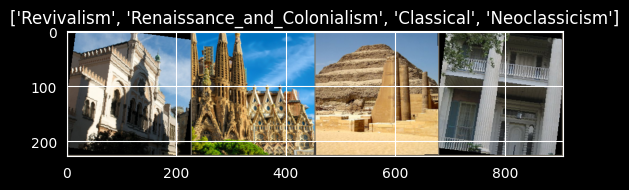

In [10]:
# Grab some of the training data to visualize
inputs, classes = next(iter(dataloaders['train']))
# Now we construct a grid from batch
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

# Загрузка и обучение модели

## Модель без заморозки слоев

In [12]:
# Setting up the model
# load in pretrained and reset final fully connected
#res_mod = models.resnet18(pretrained=True)
res_mod = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = res_mod.fc.in_features
res_mod.fc = nn.Linear(num_ftrs, 9)
for name, child in res_mod.named_children(): print(name)

conv1
bn1
relu
maxpool
layer1
layer2
layer3
layer4
avgpool
fc


In [13]:
res_mod = res_mod.to(device)
criterion = nn.CrossEntropyLoss()
# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(res_mod.parameters(), lr=0.001, momentum=0.9)
# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

## Функция для обучения и валидации

In [11]:
def train_func(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_top3 = 0.0
    best_f1 = 0.0

    for epoch in range(num_epochs):
        epoch_time = time.time()
        print('Epoch {}/{}'.format(epoch + 1, num_epochs))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:

            all_preds = []
            all_labels = []
            all_probs = []

            if phase == 'train':
                model.train() # Set model to training mode
            else: model.eval() # Set model to evaluate mode

            current_loss = 0.0
            current_corrects = 0

            print('Iterating through data...')

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Time to carry out the forward training poss
                # We only need to log the loss stats if we are in training phase
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # We want variables to hold the loss statistics
                current_loss += loss.item() * inputs.size(0)
                current_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(outputs.detach().cpu().numpy())

            epoch_f1 = f1_score(all_labels, all_preds, average='macro')
            epoch_top3 = top_k_accuracy_score(all_labels, np.vstack(all_probs), k=3)
            epoch_loss = current_loss / dataset_sizes[phase]
            epoch_acc = current_corrects / dataset_sizes[phase]

            print('{} Loss: {:.4f} | Acc: {:.4f} | F1-macro: {:.4f} | Top-3 Acc: {:.4f}'.format( phase, epoch_loss, epoch_acc, epoch_f1, epoch_top3))

            if phase == 'train':
                scheduler.step()

            if phase == 'val' and (epoch_f1 > best_f1 or (epoch_top3 > best_top3 and epoch_f1 >= best_f1)):
                best_f1 = epoch_f1
                best_top3 = epoch_top3 if epoch_top3 > best_top3 else best_top3
                best_acc = epoch_acc if epoch_acc > best_acc else best_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            del all_preds, all_labels, all_probs
        print('Epoch Time: {:.4f}s'.format(time.time() - epoch_time))
        print()

    time_since = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format( time_since // 60, time_since % 60))
    print('Best val Acc: {:4f} | Best F1-score: {:.4f} | Best Top-3 Acc: {:.4f}'.format(best_acc, best_f1, best_top3))

    # Now we'll load in the best model weights and return it
    model.load_state_dict(best_model_wts)
    return model

In [ ]:
base_fulltrain = train_model(res_mod, criterion, optimizer_ft, exp_lr_scheduler, dataloaders, dataset_sizes, 25)

In [11]:
vis_loader = torch.utils.data.DataLoader(
    chosen_datasets['val'],
    batch_size=4,
    shuffle=True,   # только для визуализации
    num_workers=4
)

def visualize_model_base(model, num_images=6):
    was_training = model.training
    model.eval()
    images_handeled = 0
    fig = plt.figure(figsize=(6, 8))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(vis_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_handeled += 1
                ax = plt.subplot(num_images//2, 2, images_handeled)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}\nreal: {class_names[labels[j]]}', fontsize=10)
                imshow(inputs.cpu().data[j])
                if images_handeled == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [ ]:
visualize_model(base_fulltrain, num_images=6)
plt.show()

## Модель с заморозкой слоев, кроме последнего

In [12]:
res_mod = models.resnet18(weights='IMAGENET1K_V1')

res_mod.fc = nn.Linear(res_mod.fc.in_features, 9)

In [13]:
res_mod.children

<bound method Module.children of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [14]:
for name, child in res_mod.named_children():
     if name == 'fc':
         print(name + 'has been unfrozen.')
         for param in child.parameters():
             param.requires_grad = True
     else:
        for param in child.parameters():
            param.requires_grad = False

num_ftrs = res_mod.fc.in_features
res_mod.fc = nn.Linear(num_ftrs, 9)

res_mod = res_mod.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_conv = torch.optim.SGD(filter(lambda x: x.requires_grad, res_mod.parameters()), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

fchas been unfrozen.


In [15]:
base_model, base_metrics = train_model(res_mod, criterion, optimizer_conv, exp_lr_scheduler, dataloaders, dataset_sizes, num_epochs=25)

val Loss: 1.1527 | Acc: 0.6059 | Weighted Acc: 0.5600 | F1-macro: 0.5978 | Top-1 Acc: 0.6059 | Top-3 Acc: 0.8779
⏳️ No improvements: 5/10
Epoch Time: 18.3934s

Training complete in 7m 39s
Best val Weighted Acc: 0.583555 | Best F1-score: 0.6163 | Best Top-1 Acc: 0.6262 | Best Top-3 Acc: 0.8868


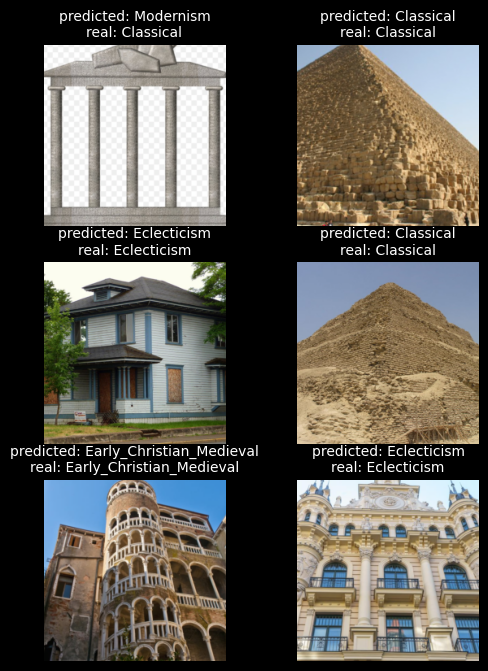

In [16]:
visualize_model(base_model, num_images=6, class_names=class_names, vis_loader=vis_loader)

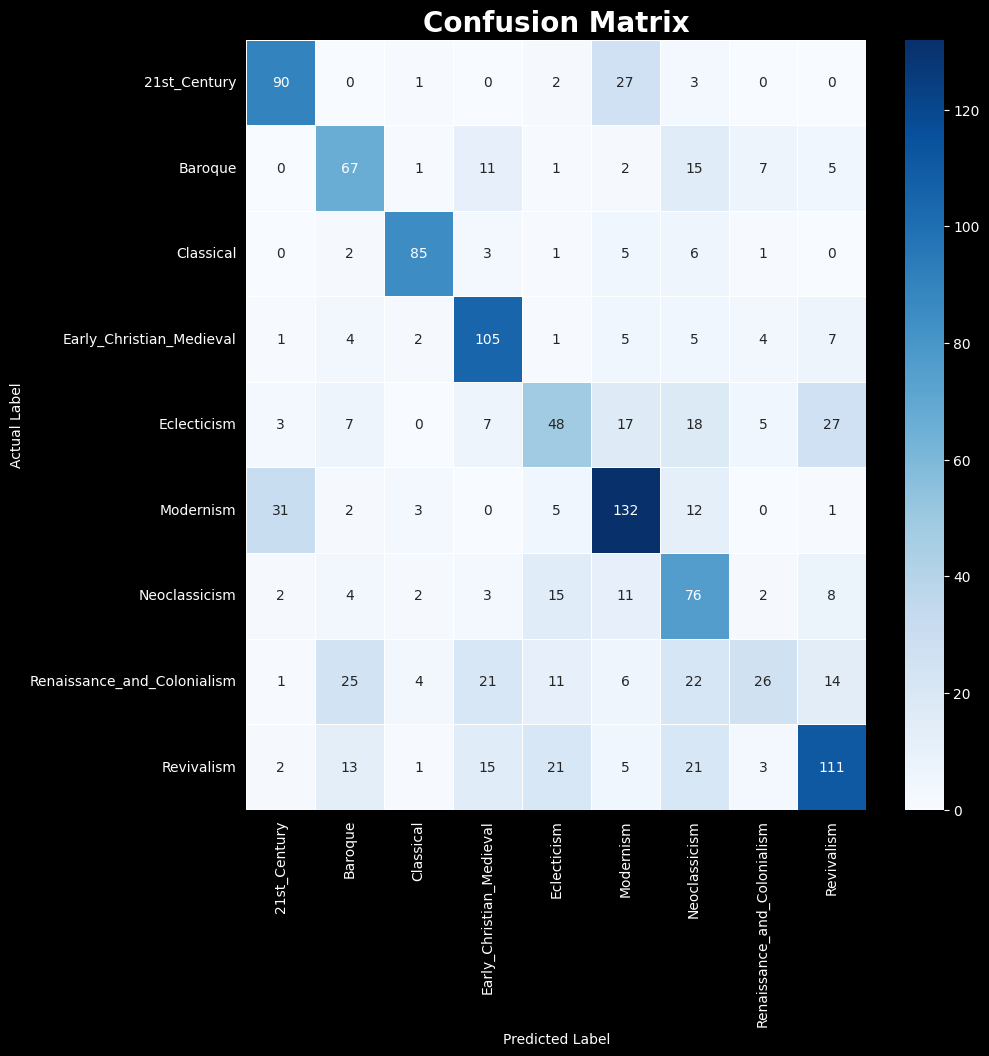

In [17]:
visualize_cm(base_model, class_names, dataloaders['test'])

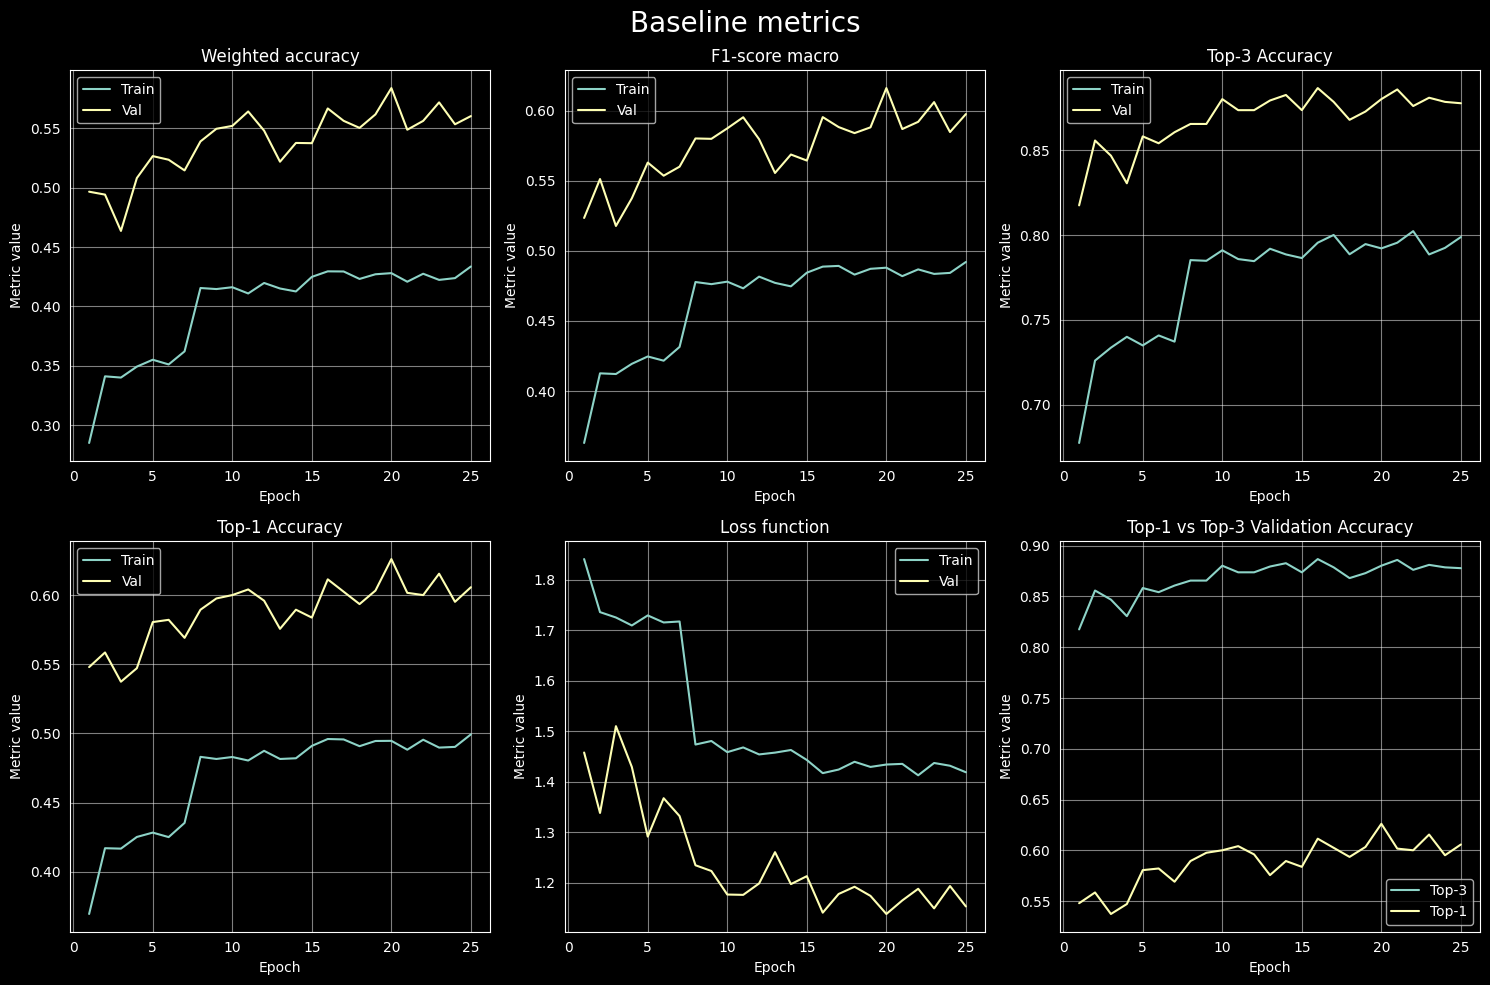

In [18]:
visualize_metrics(base_metrics, 'Baseline metrics', len(base_metrics[0]))

In [24]:
torch.save(base_model.state_dict(), 'base_model.pt')